In [ ]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

In [4]:
from dotenv import load_dotenv
import os

load_dotenv()

SUPABASE_CONNECTION = os.getenv('SUPABASE_CONNECTION')
conn = psycopg2.connect(SUPABASE_CONNECTION)
print(conn)


<connection object at 0x000001C731ED3DE0; dsn: 'user=postgres.qzcdlidgciuzddcyunrj password=xxx dbname=postgres host=aws-1-ca-central-1.pooler.supabase.com port=5432', closed: 0>


In [5]:
query = "SELECT * FROM client_risk_summary;"
df = pd.read_sql(query, conn)

print("Data Loaded Successfully")
print(df.head())

C:\Users\moham\AppData\Local\Temp\ipykernel_13704\2154989556.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Data Loaded Successfully
   client_id  total_transactions  avg_amount  large_amount_count  \
0          1                1124       62.32                  22   
1          2                 699       70.49                  18   
2          3                 365       58.39                  11   
3          4                1523       60.01                  43   
4          5                 735       63.06                  22   

   high_velocity_count  risk_score risk_level  
0                    0           1     Medium  
1                    0           1     Medium  
2                    0           1     Medium  
3                    0           1     Medium  
4                    0           1     Medium  



Risk Distribution:
 risk_level
Medium    925
Low        72
Name: count, dtype: int64


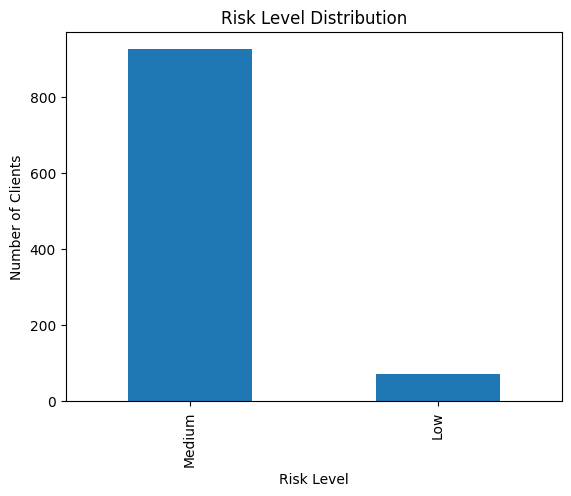

In [6]:
risk_counts = df['risk_level'].value_counts()
print("\nRisk Distribution:\n", risk_counts)

plt.figure()
risk_counts.plot(kind='bar')
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Clients")
plt.show()

In [7]:
top_clients = df.sort_values('risk_score', ascending=False).head(10)
print("\nTop 10 High-Risk Clients:\n", top_clients)


Top 10 High-Risk Clients:
      client_id  total_transactions  avg_amount  large_amount_count  \
996        997                 735       66.45                  22   
0            1                1124       62.32                  22   
1            2                 699       70.49                  18   
2            3                 365       58.39                  11   
3            4                1523       60.01                  43   
980        981                 360       73.45                  13   
979        980                1083       65.68                  24   
977        978                1076       59.82                  28   
976        977                1469       93.96                  55   
975        976                 732       62.44                  15   

     high_velocity_count  risk_score risk_level  
996                    0           1     Medium  
0                      0           1     Medium  
1                      0           1     Medium  
2


Average Transactions by Risk Level:
 risk_level
Low         14.125000
Medium    1000.194595
Name: total_transactions, dtype: float64


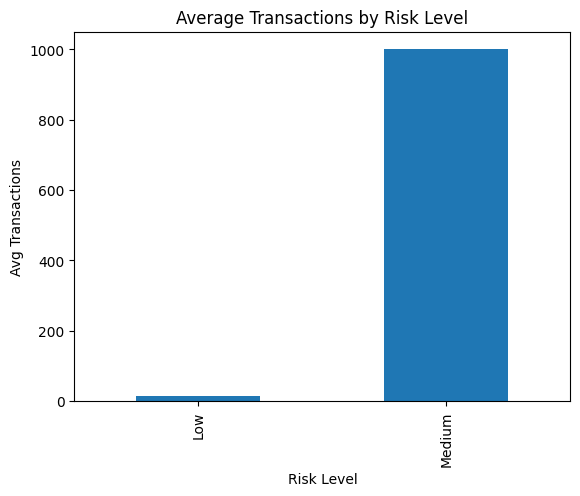

In [8]:
avg_tx_by_risk = df.groupby('risk_level')['total_transactions'].mean()
print("\nAverage Transactions by Risk Level:\n", avg_tx_by_risk)

plt.figure()
avg_tx_by_risk.plot(kind='bar')
plt.title("Average Transactions by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Avg Transactions")
plt.show()



Average Transaction Amount by Risk Level:
 risk_level
Low       574.600417
Medium     83.465643
Name: avg_amount, dtype: float64


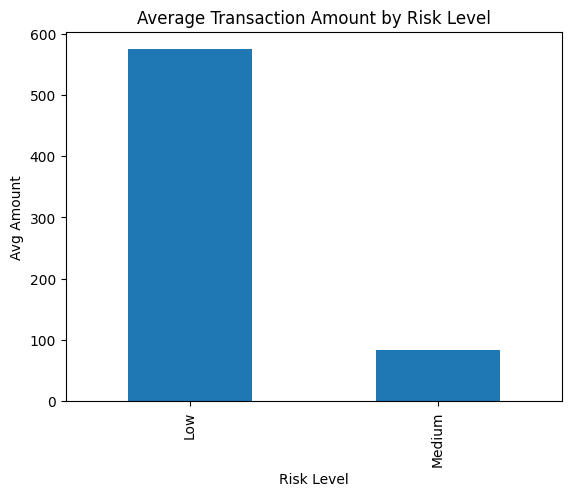

In [10]:

avg_amount = df.groupby('risk_level')['avg_amount'].mean()
print("\nAverage Transaction Amount by Risk Level:\n", avg_amount)

plt.figure()
avg_amount.plot(kind='bar')
plt.title("Average Transaction Amount by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Avg Amount")
plt.show()

In [11]:
total_clients = len(df)
high_risk_clients = len(df[df['risk_level'] == 'High'])

print("\nHigh-risk client %:", round(high_risk_clients / total_clients, 4))

# -------------------------------
# CLOSE CONNECTION
# -------------------------------

conn.close()


High-risk client %: 0.0
